# 05. Chốt mặt bằng cơ sở

Ghép kết quả từ
- `feature_selection_baseline_results`
- `linear_models_results`

Sau đó vẽ chart tổng hợp và chọn top 2-3 baseline model tốt nhất


In [ ]:
import sys
import json
from pathlib import Path

current_path = Path.cwd().resolve()
candidate_paths = [current_path, *current_path.parents]
PROJECT_ROOT = next(
    (
        path for path in candidate_paths
        if (path / 'data').exists() and (path / 'src').exists()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        'Không thể tự động xác định thư mục dự án AbaloneAge. '
    )
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Image, display


## 1. Khai báo đường dẫn và helper


In [2]:
METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, output_stem):
    df.to_csv(output_stem.with_suffix('.csv'), index=False)
    output_stem.with_suffix('.json').write_text(
        json.dumps(df.to_dict(orient='records'), indent=2),
        encoding='utf-8',
    )


## 2. Nạp các bảng kết quả cơ sở


In [3]:
feature_results = pd.read_csv(METRICS_DIR / 'feature_selection_baseline_results.csv')
linear_results = pd.read_csv(METRICS_DIR / 'linear_models_results.csv')
linear_results['experiment_name'] = linear_results['model_name']
linear_results['family'] = 'linear_models'

print('feature_results:', feature_results.shape)
print('linear_results:', linear_results.shape)


feature_results: (14, 11)
linear_results: (7, 15)


## 3. Tổng hợp kết quả cơ sở và xếp hạng


In [4]:
final_baseline = pd.concat(
    [
        feature_results.assign(source_notebook='03_feature_selection_baseline'),
        linear_results.assign(source_notebook='04_model_linear_models'),
    ],
    ignore_index=True,
    sort=False,
)

final_baseline['rmse_rank'] = final_baseline['test_rmse'].rank(method='dense')
final_baseline['mae_rank'] = final_baseline['test_mae'].rank(method='dense')
final_baseline['r2_rank'] = final_baseline['test_r2'].rank(method='dense', ascending=False)
final_baseline['overall_rank_score'] = final_baseline['rmse_rank'] + final_baseline['mae_rank'] + final_baseline['r2_rank']

final_baseline = final_baseline.sort_values(['overall_rank_score', 'test_rmse', 'test_mae']).reset_index(drop=True)
final_baseline['final_rank'] = range(1, len(final_baseline) + 1)
display(final_baseline)


,experiment_name,family,model_name,dataset_variant,cv_rmse,cv_mae,test_rmse,test_mae,test_r2,cv_time_sec,...,source_notebook,group_name,cv_rse,test_rse,rank_in_group,rmse_rank,mae_rank,r2_rank,overall_rank_score,final_rank
0,MLPRegressor,linear_models,MLPRegressor,robust_log_scaled,2.173823,1.499122,2.109222,1.503208,0.561890,18.114501,...,04_model_linear_models,linear_models,0.450625,0.438110,1.0,1.0,3.0,1.0,5.0,1
1,svr_standard,linear_probe,SVR,standard_scaled,2.180578,1.482348,2.160870,1.491397,0.540171,2.772083,...,03_feature_selection_baseline,NaN,NaN,NaN,NaN,2.0,1.0,2.0,5.0,2
2,svr_robust,linear_probe,SVR,robust_log_scaled,2.197660,1.490488,2.174461,1.495234,0.534368,2.243187,...,03_feature_selection_baseline,NaN,NaN,NaN,NaN,4.0,2.0,4.0,10.0,3
3,SVR,linear_models,SVR,robust_log_scaled,2.197660,1.490488,2.174461,1.495234,0.534368,1.894501,...,04_model_linear_models,linear_models,0.460561,0.465632,3.0,4.0,2.0,4.0,10.0,4
4,LinearSVR,linear_models,LinearSVR,robust_log_scaled,2.243512,1.543189,2.175788,1.517793,0.533800,0.072255,...,04_model_linear_models,linear_models,0.479980,0.466200,4.0,5.0,4.0,5.0,14.0,5
5,ridge_regression_robust,linear_probe,RidgeRegression,robust_log_scaled,2.188713,1.566469,2.166889,1.557175,0.537606,0.035930,...,03_feature_selection_baseline,NaN,NaN,NaN,NaN,3.0,9.0,3.0,15.0,6
6,RidgeRegression,linear_models,RidgeRegression,robust_log_scaled,2.188713,1.566469,2.166889,1.557175,0.537606,0.025312,...,04_model_linear_models,linear_models,0.456819,0.462394,2.0,3.0,9.0,3.0,15.0,7
7,boosting_encoded,tree_probe,GradientBoostingRegressor,encoded_only,2.171701,1.530359,2.179970,1.539953,0.532006,3.562551,...,03_feature_selection_baseline,NaN,NaN,NaN,NaN,8.0,5.0,8.0,21.0,8
8,linear_regression_robust,linear_probe,LinearRegression,robust_log_scaled,2.184263,1.568446,2.177008,1.559670,0.533277,0.027781,...,03_feature_selection_baseline,NaN,NaN,NaN,NaN,6.0,10.0,6.0,22.0,9
9,LinearRegression,linear_models,LinearRegression,robust_log_scaled,2.184263,1.568446,2.177008,1.559670,0.533277,0.086999,...,04_model_linear_models,linear_models,0.454963,0.466723,5.0,6.0,10.0,6.0,22.0,10


## 4. Top 3 mô hình cơ sở


In [5]:
top_models = final_baseline.head(3).copy()
display(top_models[['model_name', 'dataset_variant', 'test_rmse', 'test_mae', 'test_r2', 'source_notebook']])


,model_name,dataset_variant,test_rmse,test_mae,test_r2,source_notebook
0,MLPRegressor,robust_log_scaled,2.109222,1.503208,0.561890,04_model_linear_models
1,SVR,standard_scaled,2.160870,1.491397,0.540171,03_feature_selection_baseline
2,SVR,robust_log_scaled,2.174461,1.495234,0.534368,03_feature_selection_baseline


## 5. Vẽ biểu đồ tổng hợp kết quả cơ sở


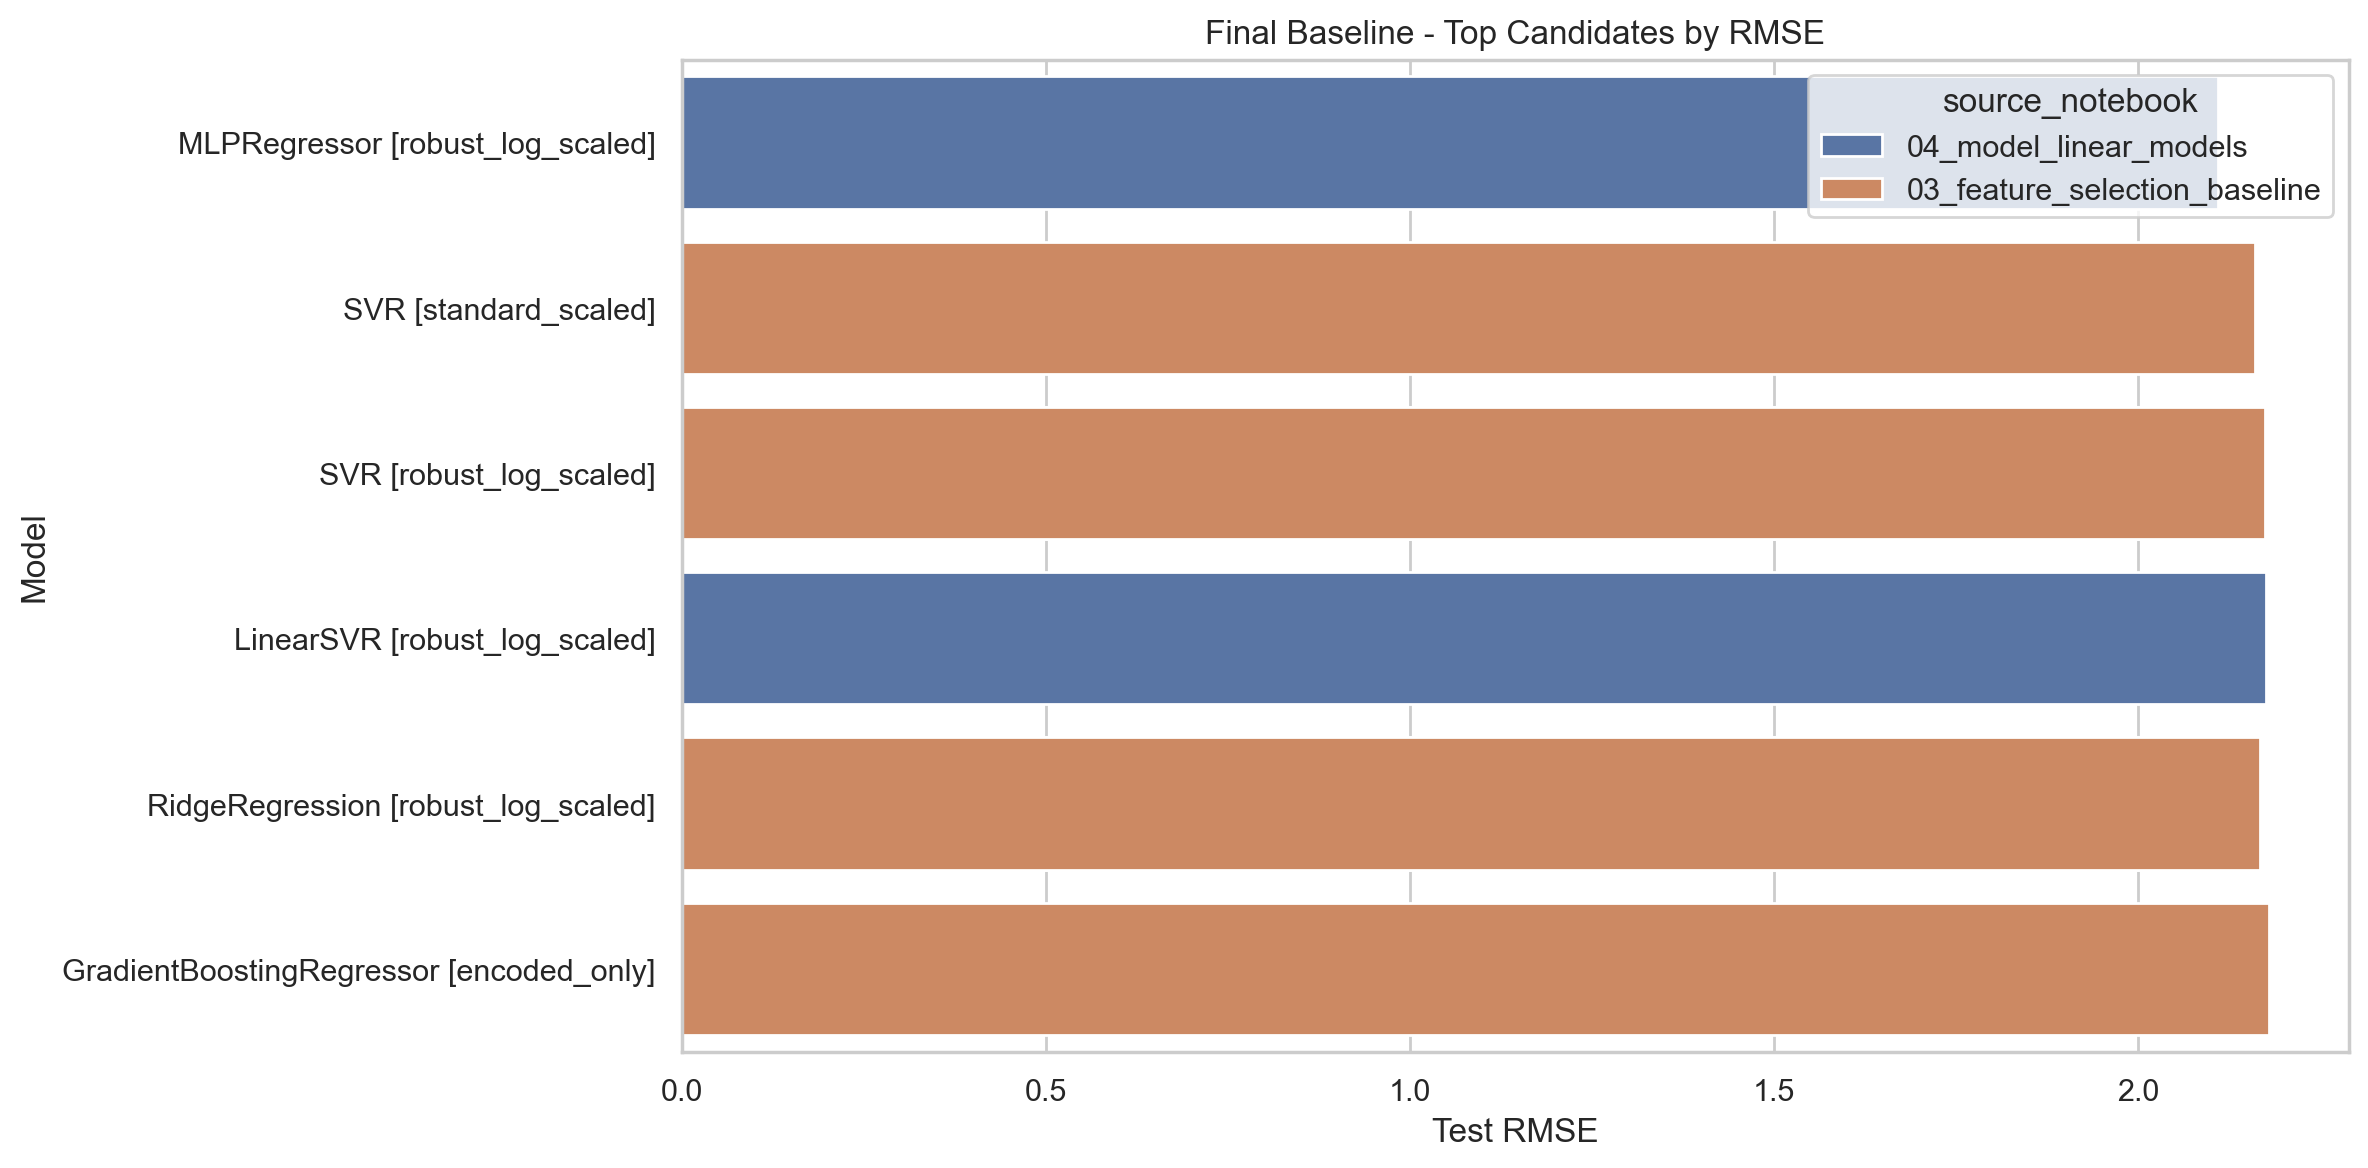

In [6]:
plot_df = final_baseline.head(min(8, len(final_baseline))).copy()
plot_df['display_name'] = plot_df['model_name'] + ' [' + plot_df['dataset_variant'] + ']'

sns.set_theme(style='whitegrid')
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=plot_df, x='test_rmse', y='display_name', hue='source_notebook', dodge=False, ax=ax)
ax.set_title('Final Baseline - Top Candidates by RMSE')
ax.set_xlabel('Test RMSE')
ax.set_ylabel('Model')
fig.tight_layout()

figure_path = FIGURES_DIR / 'final_baseline_overview.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(figure_path)))


## 6. Lưu kết quả cuối cùng


In [7]:
save_table(final_baseline, METRICS_DIR / 'final_baseline_results')
save_table(top_models, METRICS_DIR / 'final_baseline_top_models')
print('Đã lưu final baseline vào outputs/metrics/ và outputs/figures/.')


Đã lưu final baseline vào outputs/metrics/ và outputs/figures/.
